In [204]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Preparation

In [205]:
# load the timeseries data in
one = pd.read_csv("data/FOREXCOM_NAS100, 60_2f4cb.csv")
two = pd.read_csv("data/FOREXCOM_NAS100, 60_b7d08.csv")

# concat the two datasets into one
nasdaq = pd.concat([one, two], axis=0, ignore_index=True)
nasdaq.to_csv("data/nasdaq.csv")

In [206]:
nasdaq.head()

,time,open,high,low,close,VWAP,Upper Band,Lower Band,Middle of Bands,Slow MA,VWAP.1
0,2019-01-02T00:00:00+01:00,6335.7,6366.3,6331.6,6359.7,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02T01:00:00+01:00,6359.6,6371.2,6356.9,6364.8,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-02T02:00:00+01:00,6364.9,6371.1,6330.3,6332.1,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-02T03:00:00+01:00,6332.2,6333.9,6279.4,6293.4,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-02T04:00:00+01:00,6293.3,6294.9,6281.3,6290.3,NaN,NaN,NaN,NaN,NaN,NaN


In [207]:
nasdaq.shape

(46433, 11)

In [208]:
nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46433 entries, 0 to 46432
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             46433 non-null  object 
 1   open             46433 non-null  float64
 2   high             46433 non-null  float64
 3   low              46433 non-null  float64
 4   close            46433 non-null  float64
 5   VWAP             0 non-null      float64
 6   Upper Band       46325 non-null  float64
 7   Lower Band       46325 non-null  float64
 8   Middle of Bands  46325 non-null  float64
 9   Slow MA          46389 non-null  float64
 10  VWAP.1           0 non-null      float64
dtypes: float64(10), object(1)
memory usage: 3.9+ MB


In [209]:
nasdaq[nasdaq["time"].str.contains(r"^\d{4}-\d{2}-\d{2}T23")]

,time,open,high,low,close,VWAP,Upper Band,Lower Band,Middle of Bands,Slow MA,VWAP.1
46,2019-01-03T23:00:00+01:00,6161.9,6161.9,6161.9,6161.9,NaN,NaN,NaN,NaN,39.992779,NaN
93,2019-01-07T23:00:00+01:00,6492.1,6492.1,6492.1,6492.1,NaN,71.322016,56.094332,63.708174,63.986113,NaN
117,2019-01-08T23:00:00+01:00,6540.5,6540.5,6540.5,6540.5,NaN,67.972176,56.570632,62.271404,59.116859,NaN
141,2019-01-09T23:00:00+01:00,6591.5,6591.5,6591.5,6591.5,NaN,65.620202,55.805743,60.712973,57.866596,NaN
165,2019-01-10T23:00:00+01:00,6614.1,6614.1,6614.1,6614.1,NaN,64.070243,45.346996,54.708619,59.002604,NaN
...,...,...,...,...,...,...,...,...,...,...,...
46156,2026-09-02T23:00:00+02:00,29096.5,29096.5,29096.0,29096.0,NaN,49.067484,32.202791,40.635138,47.863474,NaN
46291,2026-09-10T23:00:00+02:00,29115.7,29116.0,29115.7,29116.0,NaN,50.902862,34.382745,42.642804,37.563880,NaN
46338,2026-09-14T23:00:00+02:00,29171.7,29171.7,29171.1,29171.1,NaN,61.158814,31.356994,46.257904,51.826591,NaN
46362,2026-09-15T23:00:00+02:00,28971.3,28971.3,28971.1,28971.1,NaN,55.155227,39.283303,47.219265,44.010164,NaN


Some of the 23 hour data are missing. First I will leave it in the dataset, them I will remove and see how the model performs.

In [210]:
close = nasdaq["close"].copy()

In [211]:
close.isna().sum()

np.int64(0)

In [212]:
close.duplicated().sum() # safe to ignore, if datetime is added, then these duplicates disappear

np.int64(4743)

Since the Nasdaq changed price regions over the years applying minmax or standardscaler would distort the ingestion pipeline. First I need to extract the market dynamics and move away from price levels to logarithmic returns. This is the same over the years.

Text(0.5, 0, 'Log-returns')

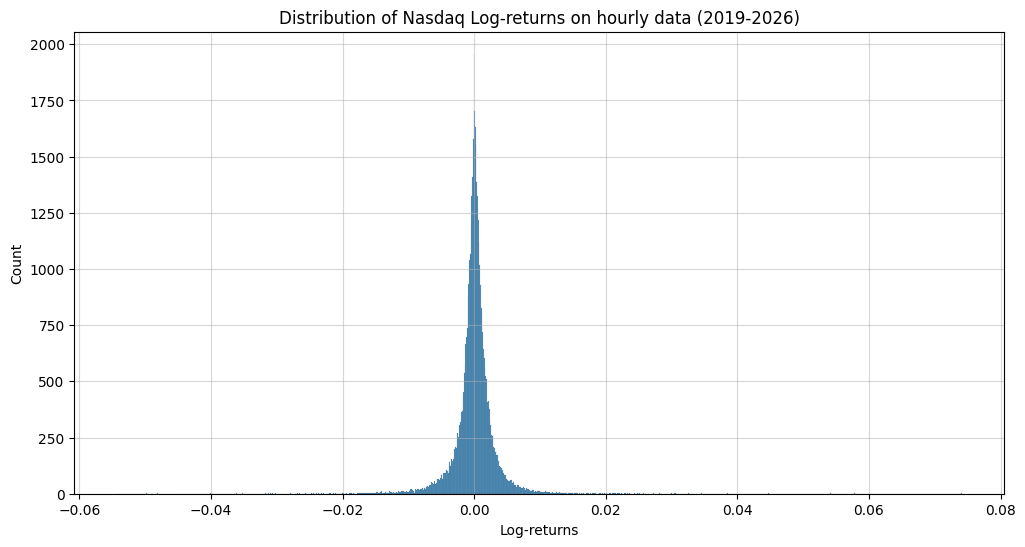

In [213]:
log_returns = np.log(close / close.shift(1))
log_returns = log_returns.dropna()
plt.figure(figsize=[12,6])
plt.grid(alpha=0.5, zorder=2)
sns.histplot(log_returns)
plt.title("Distribution of Nasdaq Log-returns on hourly data (2019-2026)", zorder=1)
plt.xlabel("Log-returns")

In [214]:
from sklearn.preprocessing import StandardScaler

In [215]:
scaler = StandardScaler()

length = len(log_returns)
train = log_returns[:int(length * 0.7)]
valid = log_returns[int(length * 0.7):int(length * 0.85)]
test = log_returns[int(length * 0.85):]

train_scaled = scaler.fit_transform(train.to_numpy().reshape(-1,1))
valid_scaled = scaler.transform(valid.to_numpy().reshape(-1,1))
test_scaled = scaler.transform(test.to_numpy().reshape(-1,1))

print(train_scaled.shape)
print(valid_scaled.shape)
print(test_scaled.shape)

(32502, 1)
(6965, 1)
(6965, 1)


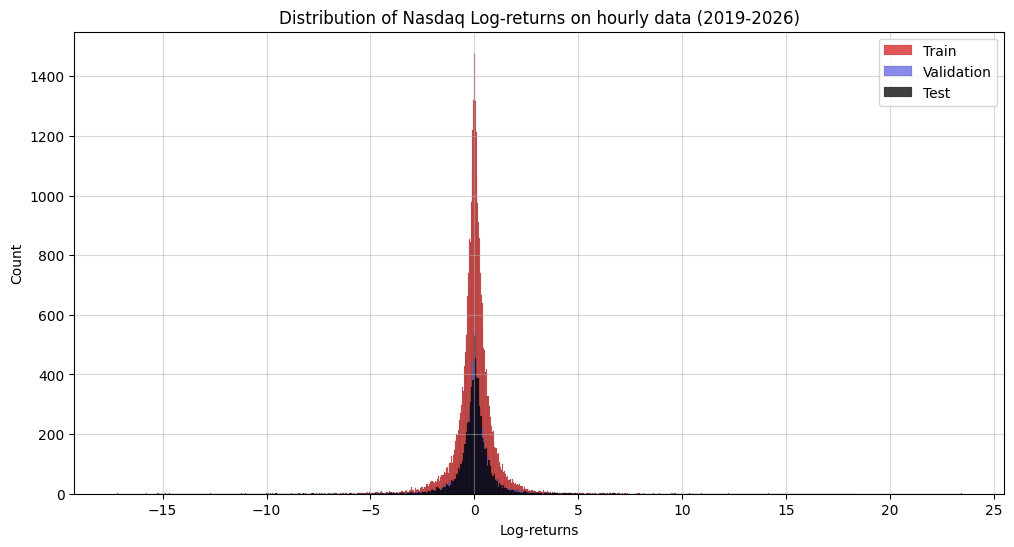

In [216]:
plt.figure(figsize=[12,6])
plt.grid(alpha=0.5, zorder=2)
sns.histplot(train_scaled.flatten(), label="Train", color="#D81E1E", fill=True)
sns.histplot(valid_scaled.flatten(), label="Validation", color="#6165E6", fill=True)
sns.histplot(test_scaled.flatten(), label="Test", color="#000000", fill=True)
plt.title("Distribution of Nasdaq Log-returns on hourly data (2019-2026)", zorder=1)
plt.xlabel("Log-returns")
plt.legend()
plt.show()

This plot reassures that the log-returns are stationaty and they catch the nasdaq`s dynamics. All three of the sets cleanly center around the mean. The huge skewness to the right and to the left is not surprising. It is a asset market, where human emotion and speculation is involved.

# 2. Data Ingestion Pipeline

## 2.1 Predicting the next hourly candle close

In [289]:
steps_in = 50
steps_out = 5
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
train_df = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
)

valid_df = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

test_df = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_df = train_df.map(split_window)
valid_df = valid_df.map(split_window)
test_df = test_df.map(split_window)

### Plotting log-returns and close data

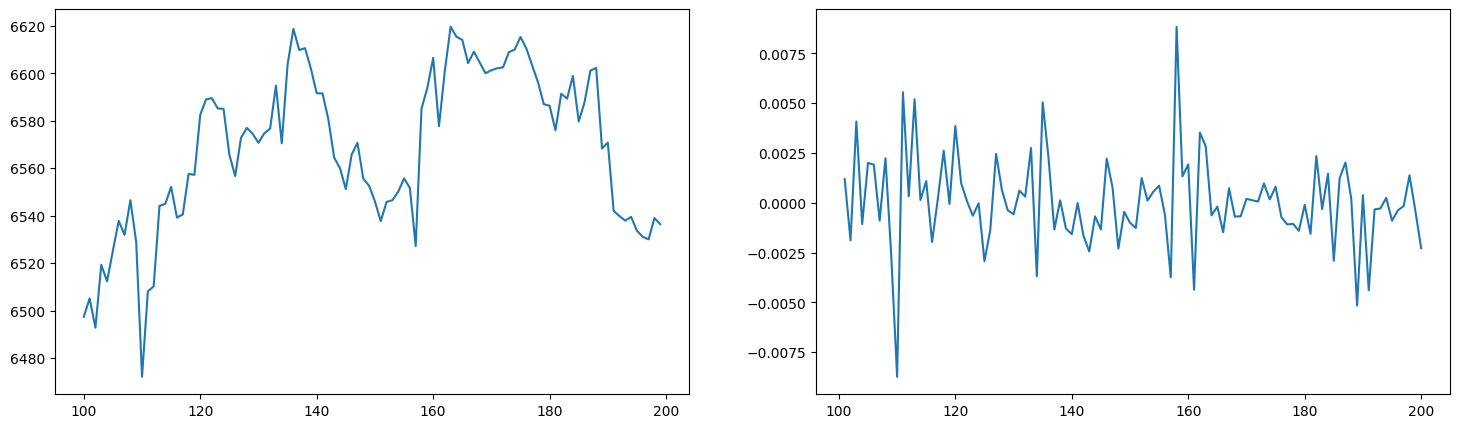

In [290]:
plt.figure(figsize=[18,5])
plt.subplot(1,2,1)
plt.plot(nasdaq["close"][100:200])

plt.subplot(1,2,2)
plt.plot(log_returns[100:200])

## 2.2 Using Window Re-basing to make price history stationary.

In [336]:
INPUT_WIDTH = 50
LABEL_WIDTH = 5
TOTAL_WINDOW = INPUT_WIDTH + LABEL_WIDTH
BATCH_SIZE = 32

def create_relative_dataset(price_array, is_training=True):
    # Ensure 1D float32 array
    prices = np.squeeze(price_array).astype(np.float32)
    
    # 1. Create raw sliding windows of length TOTAL_WINDOW
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=prices,
        targets=None,
        sequence_length=TOTAL_WINDOW,
        sequence_stride=1,
        sampling_rate=1,
        batch_size=None,  # Stream individual windows first
        shuffle=False
    )
    
    # 2. Window-relative scaling via tf.data.Dataset.map
    def scale_window(window):
        # window shape: (TOTAL_WINDOW,) 
        x_raw = window[:INPUT_WIDTH]
        y_raw = window[INPUT_WIDTH:]
        
        # Base price: last observed price in the input sequence
        base_price = x_raw[-1]
        
        # Relative scaling: (P / base_price) - 1.0
        x_scaled = (x_raw / base_price) - 1.0
        y_scaled = (y_raw / base_price) - 1.0
        
        # Add feature dimension: (INPUT_WIDTH, 1) and (LABEL_WIDTH,)
        return tf.expand_dims(x_scaled, axis=-1), y_scaled

    ds = ds.map(scale_window, num_parallel_calls=tf.data.AUTOTUNE)
    
    # 3. Shuffle (only for training), batch, and prefetch
    if is_training:
        ds = ds.shuffle(buffer_size=10000, seed=42)
        
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [338]:
data = nasdaq["close"].to_numpy()

raw_train = data[:int(len(data)*0.7)]
raw_valid = data[int(len(data)*0.7):int(len(data)*0.85)]
raw_test = data[int(len(data)*0.85):]


train_df_win_rebase = create_relative_dataset(raw_train, is_training=True)
val_df_win_rebase   = create_relative_dataset(raw_valid,   is_training=False)
test_df_win_rebase  = create_relative_dataset(raw_test,  is_training=False)

# Verify tensor shapes
for x_batch, y_batch in train_df_win_rebase.take(1):
    print("X batch shape:", x_batch.shape)  # (32, 60, 1)
    print("y batch shape:", y_batch.shape)  # (32, 5)
    print("X last timestep values (should be 0.0):", x_batch[0, -1, 0].numpy())

X batch shape: (32, 50, 1)
y batch shape: (32, 5)
X last timestep values (should be 0.0): 0.0


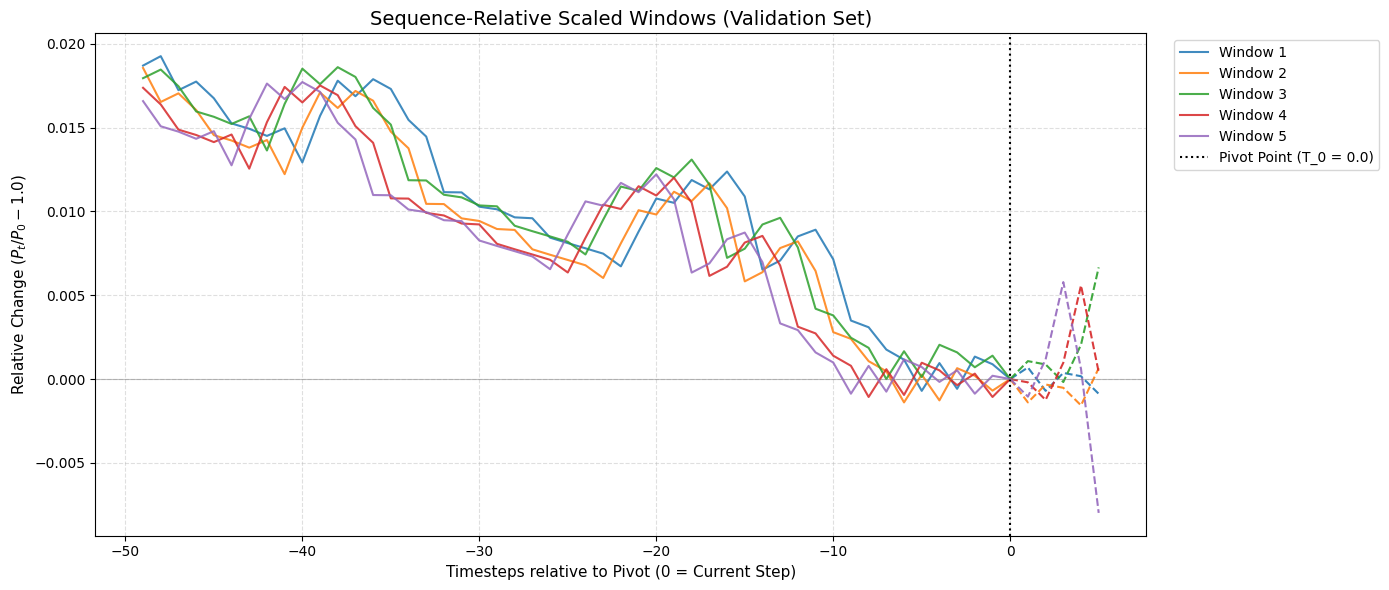

In [341]:


# 1. Grab the first batch of (X, y) windows from your validation pipeline
for x_batch, y_batch in val_df_win_rebase.take(10):
    x_windows = x_batch.numpy()  # shape: (batch_size, 60, 1)
    y_windows = y_batch.numpy()  # shape: (batch_size, 5)
    break

# 2. Plot several sample windows to inspect the shapes
plt.figure(figsize=(14, 6))

input_len = x_windows.shape[1]
pred_len = y_windows.shape[1]

# Timeline indices
t_input = np.arange(-input_len + 1, 1)   # e.g., -59 to 0
t_target = np.arange(1, pred_len + 1)    # e.g., 1 to 5

num_samples_to_plot = 5  # plot first 5 windows in the batch

for i in range(num_samples_to_plot):
    # Historical input curve
    history = x_windows[i, :, 0]
    # Future target path
    future = y_windows[i, :]
    
    # Plot input history
    line = plt.plot(t_input, history, alpha=0.85, label=f"Window {i+1}")
    color = line[0].get_color()
    
    # Plot 5-day future target path as a dashed line continuing from 0.0
    plt.plot(np.append(0, t_target), np.append(0, future), 
             linestyle="--", color=color, alpha=0.9)

plt.axvline(0, color="black", linestyle=":", linewidth=1.5, label="Pivot Point (T_0 = 0.0)")
plt.axhline(0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)

plt.title("Sequence-Relative Scaled Windows (Validation Set)", fontsize=14)
plt.xlabel("Timesteps relative to Pivot (0 = Current Step)", fontsize=11)
plt.ylabel("Relative Change $(P_t / P_0 - 1.0)$", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

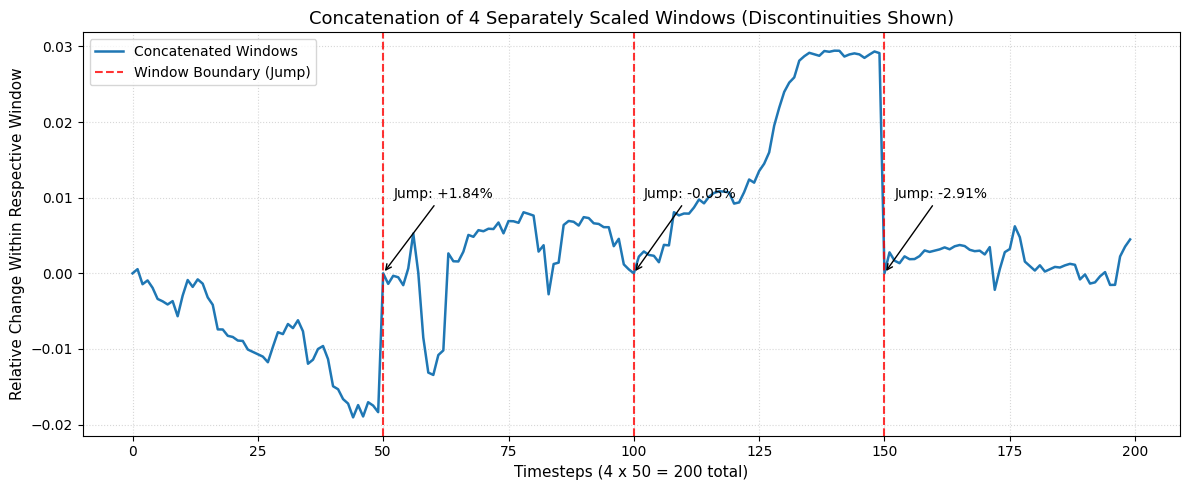

In [ ]:
WINDOW_SIZE = 50
NUM_WINDOWS = 4

# 1. Extract 4 consecutive, non-overlapping windows from raw prices
raw_slices = [
    raw_valid[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
    for i in range(NUM_WINDOWS)
]

# 2. Scale each window independently by its OWN base price (e.g. its start or end)
# Here re-basing to each window's first element: (P / P[0]) - 1.0
scaled_windows = [(w / w[0]) - 1.0 for w in raw_slices]

# 3. Concatenate the 4 independently scaled windows
concatenated_raw_scaled = np.concatenate(scaled_windows)

# 4. Plot to see the visible jumps/discontinuities
plt.figure(figsize=(12, 5))
plt.plot(concatenated_raw_scaled, color="#1f77b4", linewidth=1.8, label="Concatenated Windows")

# Draw vertical boundary markers every 50 steps
for k in range(1, NUM_WINDOWS):
    step = k * WINDOW_SIZE
    plt.axvline(step, color="red", linestyle="--", alpha=0.8, 
                label="Window Boundary (Jump)" if k == 1 else "")
    
    # Annotate the sudden step change
    jump_size = concatenated_raw_scaled[step] - concatenated_raw_scaled[step - 1]
    plt.annotate(f"Jump: {jump_size:+.2%}", 
                 xy=(step, concatenated_raw_scaled[step]),
                 xytext=(step + 2, concatenated_raw_scaled[step] + 0.01),
                 arrowprops=dict(arrowstyle="->", color="black"))

plt.title("Concatenation of 4 Separately Scaled Windows (Discontinuities Shown)", fontsize=13)
plt.xlabel("Timesteps (4 x 50 = 200 total)", fontsize=11)
plt.ylabel("Relative Change Within Respective Window", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 2.3 Window re-basing with 120 lookback

In [386]:
INPUT_WIDTH = 120
LABEL_WIDTH = 5
TOTAL_WINDOW = INPUT_WIDTH + LABEL_WIDTH
BATCH_SIZE = 32

def create_relative_dataset(price_array, is_training=True):
    # Ensure 1D float32 array
    prices = np.squeeze(price_array).astype(np.float32)
    
    # 1. Create raw sliding windows of length TOTAL_WINDOW
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=prices,
        targets=None,
        sequence_length=TOTAL_WINDOW,
        sequence_stride=1,
        sampling_rate=1,
        batch_size=None,  # Stream individual windows first
        shuffle=False
    )
    
    # 2. Window-relative scaling via tf.data.Dataset.map
    def scale_window(window):
        # window shape: (TOTAL_WINDOW,) 
        x_raw = window[:INPUT_WIDTH]
        y_raw = window[INPUT_WIDTH:]
        
        # Base price: last observed price in the input sequence
        base_price = x_raw[-1]
        
        # Relative scaling: (P / base_price) - 1.0
        x_scaled = (x_raw / base_price) - 1.0
        y_scaled = (y_raw / base_price) - 1.0
        
        # Add feature dimension: (INPUT_WIDTH, 1) and (LABEL_WIDTH,)
        return tf.expand_dims(x_scaled, axis=-1), y_scaled

    ds = ds.map(scale_window, num_parallel_calls=tf.data.AUTOTUNE)
    
    # 3. Shuffle (only for training), batch, and prefetch
    if is_training:
        ds = ds.shuffle(buffer_size=10000, seed=42)
        
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [387]:
train_df_win_rebase120 = create_relative_dataset(raw_train, is_training=True)
val_df_win_rebase120   = create_relative_dataset(raw_valid,   is_training=False)
test_df_win_rebase120  = create_relative_dataset(raw_test,  is_training=False)

# Verify tensor shapes
for x_batch, y_batch in train_df_win_rebase120.take(1):
    print("X batch shape:", x_batch.shape)  # (32, 60, 1)
    print("y batch shape:", y_batch.shape)  # (32, 5)
    print("X last timestep values (should be 0.0):", x_batch[0, -1, 0].numpy())

X batch shape: (32, 120, 1)
y batch shape: (32, 5)
X last timestep values (should be 0.0): 0.0


# 3. Building the model

In [342]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

## 3.1.1 Naive forecast

In [292]:
# extract last step of train
# extract actual next steps t+1
time_stride = 5
y_pred_1 = []
y_valid_1 = []

for x, y in valid_df:
    last_val = x[:, -1, :].numpy()
    naive_forecast = np.repeat(last_val, repeats=time_stride, axis=1)

    y_pred_1.append(naive_forecast)
    y_valid_1.append(y.numpy())

y_pred_1 = np.concatenate(y_pred_1, axis=0).reshape(-1)  
y_valid_1 = np.concatenate(y_valid_1, axis=0).reshape(-1)

mse1_naive = round(mean_squared_error(y_valid_1, y_pred_1), 4)
mape1_naive = round(mean_absolute_percentage_error(y_valid_1, y_pred_1), 2)

print(f"The MAE is: {mse1_naive} and the MAPE is: {mape1_naive}%")

The MAE is: 1.8019 and the MAPE is: 7.86%


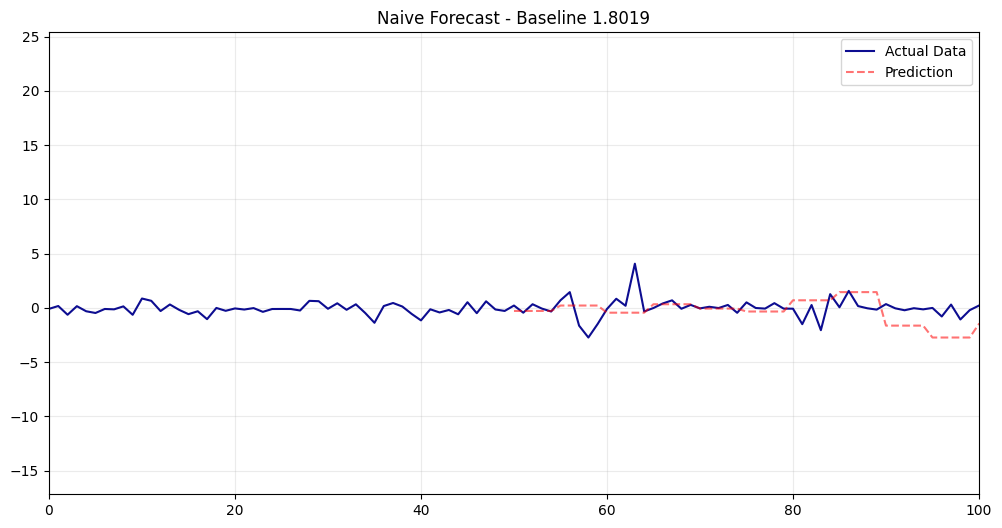

In [294]:
plt.figure(figsize=[12,6])

steps = np.arange(50, len(y_pred_1)+50, 1)
plt.plot(valid_scaled ,color="darkblue", alpha=0.95, label="Actual Data")
plt.plot(steps, y_pred_1, "r--", alpha=0.55, label="Prediction")
plt.title(f"Naive Forecast - Baseline {mse1_naive}")
plt.xlim(0,100)
plt.grid(alpha=0.25)
plt.legend()

Well, the naive forecast too simple and the market is too complex. Lets start adding more model variance.

## 3.1.2 Linear model

In [297]:
linear_model = keras.models.Sequential([
    keras.layers.Input(shape=[50,1]),
    keras.layers.Reshape((50,)),
    keras.layers.Dense(5)
])
linear_model.compile(loss="mse", metrics=["mae"], optimizer="adam")

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7
)


linear_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step - loss: 2.2572 - mae: 0.9758 - val_loss: 0.9863 - val_mae: 0.5812 - learning_rate: 0.0010
Epoch 2/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - loss: 1.0786 - mae: 0.6125 - val_loss: 0.9190 - val_mae: 0.5412 - learning_rate: 0.0010
Epoch 3/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - loss: 1.0313 - mae: 0.5909 - val_loss: 0.9194 - val_mae: 0.5412 - learning_rate: 0.0010
Epoch 4/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 1s 923us/step - loss: 1.0294 - mae: 0.5903 - val_loss: 0.9197 - val_mae: 0.5413 - learning_rate: 0.0010
Epoch 5/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - loss: 1.0324 - mae: 0.5914 - val_loss: 0.9198 - val_mae: 0.5411 - learning_rate: 0.0010
Epoch 6/50
 980/1014 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - loss: 1.0337 - mae: 0.5914
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - loss: 1.0325 - mae: 0.5913 - val_loss: 0.9195 - val_mae: 0.541

216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - loss: 0.6762 - mae: 0.4864


(5000.0, 5100.0)

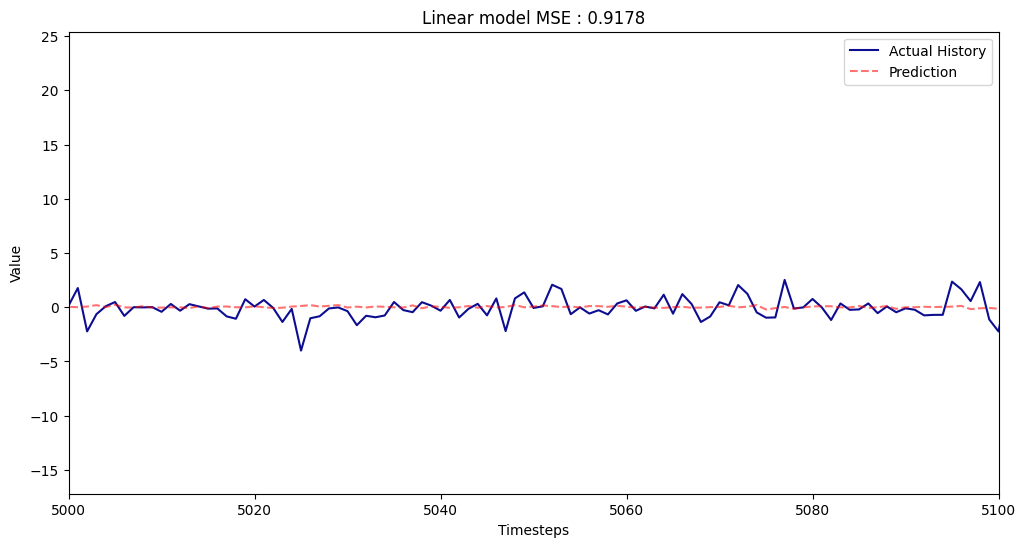

In [301]:
y_pred1_linear = linear_model.predict(valid_df)
mse1_linear = round(linear_model.evaluate(valid_df)[0],4)

steps = np.arange(50, len(y_pred1_linear)+50, 1)
plt.figure(figsize=[12, 6])
plt.plot(valid_scaled, label="Actual History", color="darkblue", alpha=0.95)
plt.plot(steps, y_pred1_linear[:,0], "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Linear model MSE : {mse1_linear}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(5000, 5100)

## 3.1.3 SimpleRNN

In [302]:
srnn_model = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.03)
srnn_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer)
srnn_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.0607 - mae: 0.6095 - val_loss: 0.9357 - val_mae: 0.5556 - learning_rate: 0.0300
Epoch 2/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0578 - mae: 0.6100 - val_loss: 0.9431 - val_mae: 0.5634 - learning_rate: 0.0300
Epoch 3/50
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0523 - mae: 0.6069 - val_loss: 0.9930 - val_mae: 0.6215 - learning_rate: 0.0300
Epoch 4/50
  77/1014 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1175 - mae: 0.6255

KeyboardInterrupt: 

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - loss: 0.6772 - mae: 0.4868


(5000.0, 5100.0)

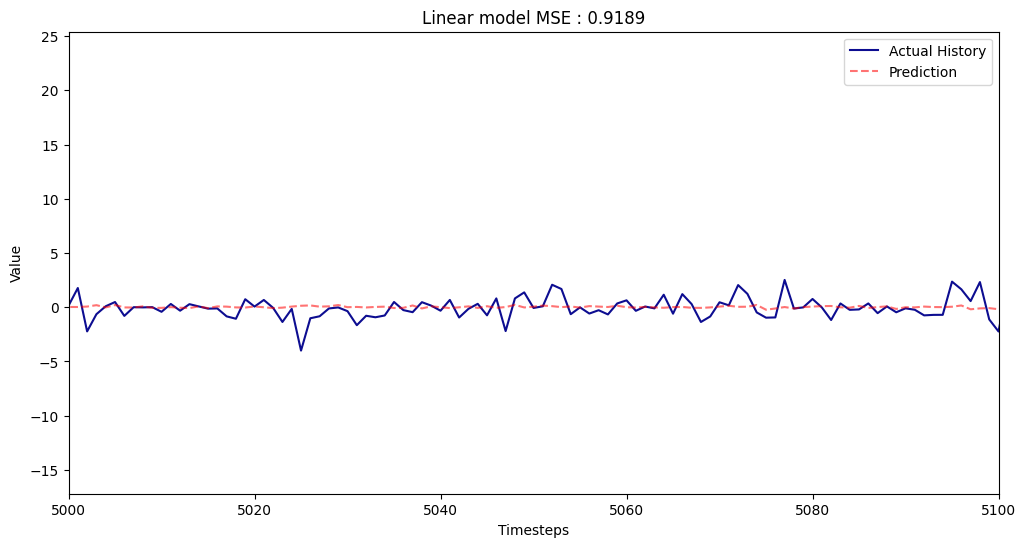

In [271]:
y_pred1_srnn = linear_model.predict(valid_df)
mse1_srnn = round(linear_model.evaluate(valid_df)[0],4)


plt.figure(figsize=[12, 6])
plt.plot(valid_scaled, label="Actual History", color="darkblue", alpha=0.95)
plt.plot(steps, y_pred1_srnn, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Linear model MSE : {mse1_srnn}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(5000, 5100)

## 3.1.4 Gru

In [273]:
gru_model = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.GRU(32),
    keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.03)
gru_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer)
gru_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 1.0395 - mae: 0.5975 - val_loss: 1.0735 - val_mae: 0.6589 - learning_rate: 0.0300
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.0874 - mae: 0.6353 - val_loss: 0.9513 - val_mae: 0.5654 - learning_rate: 0.0300
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.0614 - mae: 0.6215 - val_loss: 0.9932 - val_mae: 0.6256 - learning_rate: 0.0300
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.0754 - mae: 0.6302 - val_loss: 0.9533 - val_mae: 0.5805 - learning_rate: 0.0300
Epoch 5/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.0540 - mae: 0.6166 - val_loss: 0.9312 - val_mae: 0.5493 - learning_rate: 0.0300
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.0604 - mae: 0.6240 - val_loss: 0.9817 - val_mae: 0.5868 - learning_rate: 0.0300
Epoch 7/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.0589 - mae: 0.6193 - val_loss: 0.9481 - val_mae: 0.5577 - learning_rate:

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - loss: 0.6772 - mae: 0.4868


(5000.0, 5100.0)

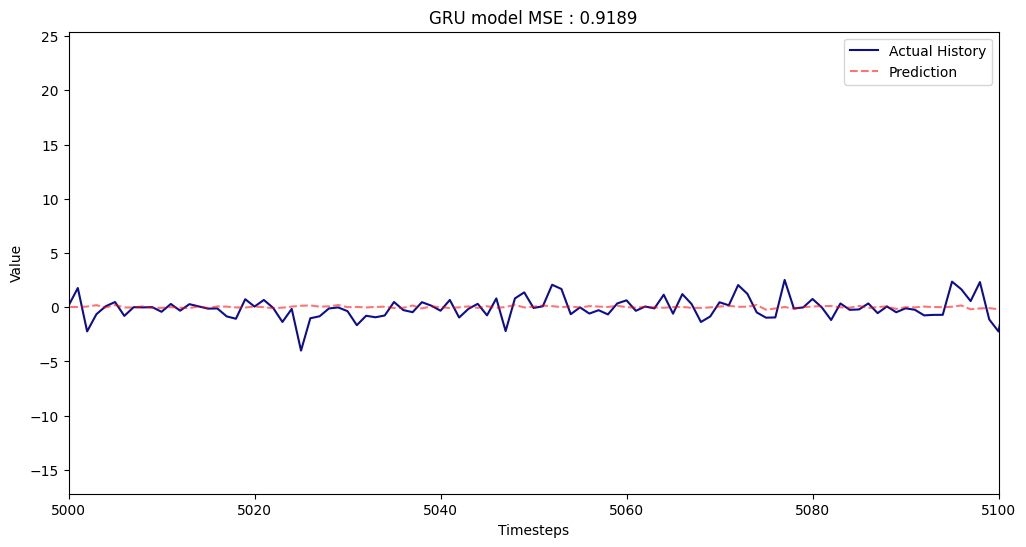

In [274]:
y_pred1_gru = linear_model.predict(valid_df)
mse1_gru = round(linear_model.evaluate(valid_df)[0],4)


plt.figure(figsize=[12, 6])
plt.plot(valid_scaled, label="Actual History", color="darkblue", alpha=0.95)
plt.plot(steps, y_pred1_gru, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"GRU model MSE : {mse1_gru}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(5000, 5100)

## 3.1.5 LSTM

In [288]:
lstm_model = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.03)
lstm_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7
)

lstm_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 65s 62ms/step - loss: 1.0350 - mae: 0.5984 - val_loss: 0.9114 - val_mae: 0.5347 - learning_rate: 0.0300
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 63s 62ms/step - loss: 1.0139 - mae: 0.5847 - val_loss: 0.9094 - val_mae: 0.5332 - learning_rate: 0.0300
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 63s 62ms/step - loss: 1.0149 - mae: 0.5847 - val_loss: 0.9108 - val_mae: 0.5342 - learning_rate: 0.0300
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 64s 63ms/step - loss: 1.0090 - mae: 0.5842 - val_loss: 0.9156 - val_mae: 0.5384 - learning_rate: 0.0300
Epoch 5/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 63s 62ms/step - loss: 1.0074 - mae: 0.5838 - val_loss: 0.9118 - val_mae: 0.5350 - learning_rate: 0.0300
Epoch 6/50
1014/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1.0114 - mae: 0.5851
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.014999999664723873.
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 63s 62ms/step - loss: 1.0114 - mae: 0.5851 - val_loss: 0.9098 - val_mae: 0.5342 

KeyboardInterrupt: 

## 3.2.1 Naive forecast MSE: 0.000028

Since the last value is always 0 in the new Window Rescaled Dataframe, the naive forecast is just 0s for 5 consecutive steps.

In [369]:
y_true_list = []
for _, y_batch in val_df_win_rebase:
    y_true_list.append(y_batch.numpy())

y_true = np.concatenate(y_true_list, axis=0) 

# 2. Create the Naive Baseline (predicting 0.0 for all 5 forward steps)
y_pred_naive = np.zeros_like(y_true)

# 3. Evaluate benchmark metrics in relative space
mse_naive = mean_squared_error(y_true, y_pred_naive)
mae_naive = mean_absolute_error(y_true, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)

print(f"--- Naive Baseline (Relative Space) ---")
print(f"MSE : {mse_naive:.6f}")
print(f"MAE : {mae_naive:.6f}")

# Per-step breakdown (error naturally grows from day 1 to day 5)
print("\nMAE by forward day:")
for day in range(5):
    step_mae = mean_absolute_error(y_true[:, day], y_pred_naive[:, day])
    print(f"Day {day + 1}: {step_mae:.4%}")

--- Naive Baseline (Relative Space) ---
MSE : 0.000028
MAE : 0.002991

MAE by forward day:
Day 1: 0.1686%
Day 2: 0.2464%
Day 3: 0.3088%
Day 4: 0.3619%
Day 5: 0.4099%


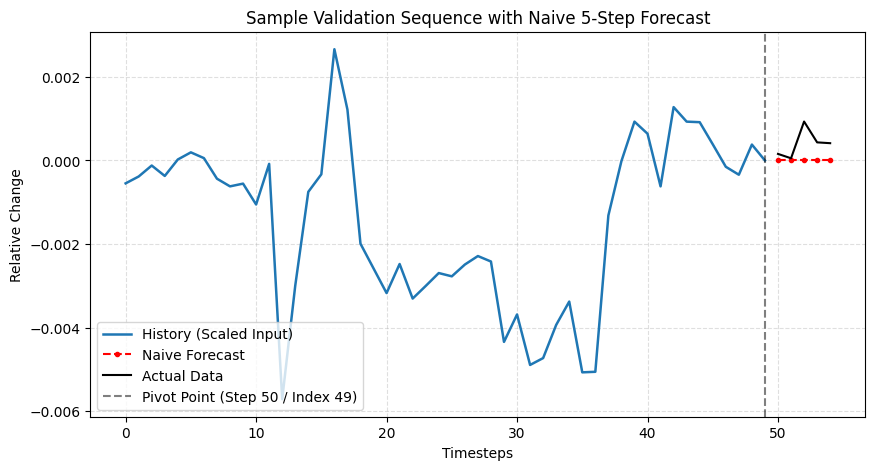

In [364]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab 1 batch from the pipeline
for x, y in val_df_win_rebase.skip(5).take(1):
    # Take the first sequence in the batch: shape (50, 1) -> flatten to (50,)
    x_history = x[0].numpy().flatten()
    y_true_sample = y[0].numpy().flatten()
    break

# 2. Naive prediction (5 steps of zeros)
y_naive = np.zeros(5)  # or y_pred_naive[0, :]

# 3. Plot input history (steps 0 to 49)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(0, 50), x_history, label="History (Scaled Input)", color="#1f77b4", linewidth=1.8)

# 4. Plot naive baseline continuing from the last point (steps 50 to 54)
plt.plot(np.arange(50, 55), y_naive, label="Naive Forecast", color="red", linestyle="--", marker=".")
plt.plot(np.arange(50, 55), y_true_sample, label="Actual Data", color="black")

# Reference lines
plt.axvline(49, color="black", linestyle="--", alpha=0.5, label="Pivot Point (Step 50 / Index 49)")

plt.title("Sample Validation Sequence with Naive 5-Step Forecast")
plt.xlabel("Timesteps")
plt.ylabel("Relative Change")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## 3.2.2 Linear model MSE: 0.000029

In [371]:
linear_model2 = keras.models.Sequential([
    keras.layers.Input(shape=[50,1]),
    keras.layers.Reshape((50,)),
    keras.layers.Dense(5)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.03)
linear_model2.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7
)


linear_model2.fit(train_df_win_rebase, validation_data=val_df_win_rebase, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - loss: 8.9863e-05 - mae: 0.0058 - val_loss: 6.5146e-05 - val_mae: 0.0060 - learning_rate: 0.0300
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - loss: 6.6198e-05 - mae: 0.0054 - val_loss: 6.7706e-05 - val_mae: 0.0061 - learning_rate: 0.0300
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - loss: 7.0302e-05 - mae: 0.0056 - val_loss: 5.4770e-05 - val_mae: 0.0053 - learning_rate: 0.0300
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - loss: 6.9106e-05 - mae: 0.0054 - val_loss: 1.7619e-04 - val_mae: 0.0104 - learning_rate: 0.0300
Epoch 5/50
 986/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - loss: 1.0912e-04 - mae: 0.0063
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.014999999664723873.
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - loss: 1.0774e-04 - mae: 0.0063 - val_loss: 7.7467e-05 - val_mae: 0.0070 - learning_rate: 0.0300
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - loss: 4.2454e-05 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


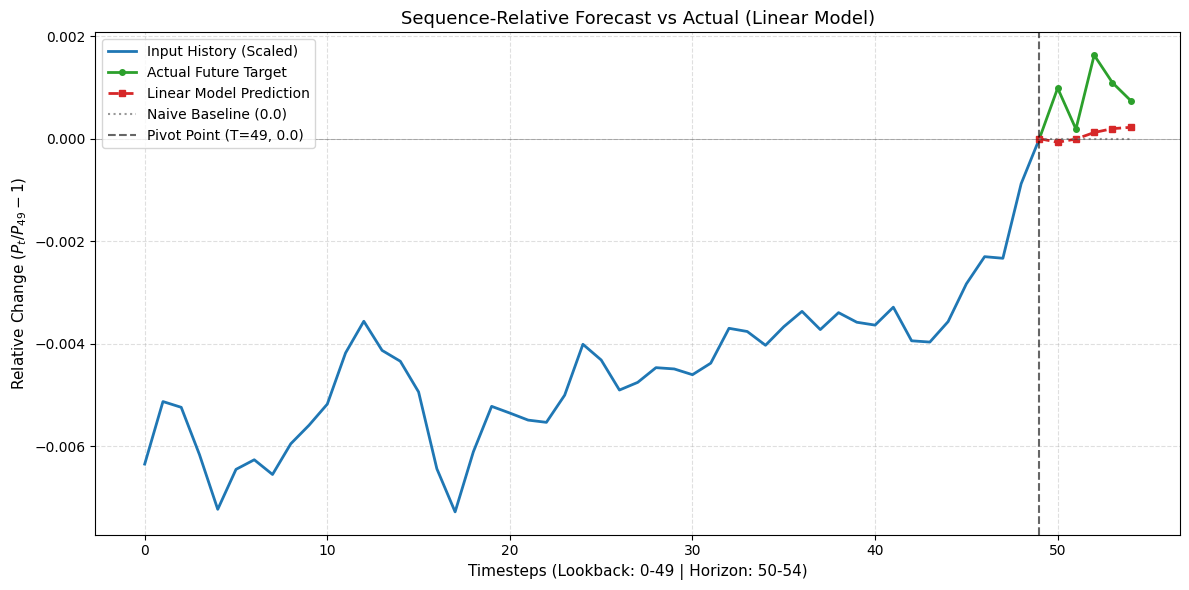

In [372]:
# 1. Grab a validation batch (skip a few batches if you want to inspect a later period)
for x_batch, y_batch in val_df_win_rebase.skip(10).take(1):
    x_val = x_batch.numpy()       # shape: (batch_size, 50, 1)
    y_true_all = y_batch.numpy()   # shape: (batch_size, 5)
    break

# 2. Run inference on the batch
y_pred_all = linear_model2.predict(x_val)  # shape: (batch_size, 5)

# 3. Choose a specific sample inside the batch to plot
sample_idx = 0

history = x_val[sample_idx].flatten()          # 50 historical steps
actual_future = y_true_all[sample_idx].flatten()  # 5 actual future steps
pred_future = y_pred_all[sample_idx].flatten()    # 5 predicted future steps

# 4. Define time axes
t_hist = np.arange(0, 50)           # 0 to 49
t_future = np.arange(49, 55)        # 49 to 54 (anchored at step 49)

# Anchor future lines to the pivot (step 49 is 0.0)
actual_line = np.insert(actual_future, 0, history[-1])
pred_line = np.insert(pred_future, 0, history[-1])

# 5. Plot
plt.figure(figsize=(12, 6))

plt.plot(t_hist, history, label="Input History (Scaled)", color="#1f77b4", linewidth=2)
plt.plot(t_future, actual_line, label="Actual Future Target", color="#2ca02c", linewidth=2, marker="o", markersize=4)
plt.plot(t_future, pred_line, label="Linear Model Prediction", color="#d62728", linestyle="--", linewidth=2, marker="s", markersize=4)

# Naive baseline reference (flat at 0.0)
plt.plot(t_future, [0.0] * len(t_future), label="Naive Baseline (0.0)", color="gray", linestyle=":", alpha=0.8)

plt.axvline(49, color="black", linestyle="--", alpha=0.6, label="Pivot Point (T=49, 0.0)")
plt.axhline(0, color="black", linestyle="-", linewidth=0.6, alpha=0.3)

plt.title("Sequence-Relative Forecast vs Actual (Linear Model)", fontsize=13)
plt.xlabel("Timesteps (Lookback: 0-49 | Horizon: 50-54)", fontsize=11)
plt.ylabel("Relative Change $(P_t / P_{49} - 1)$", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [373]:
# 1. Run inference across the full validation dataset
val_loss, val_mae = linear_model2.evaluate(val_df_win_rebase, verbose=0)

# 2. Extract true targets to evaluate the Naive Baseline (zeros)
y_val_true_list = []
for _, y_batch in val_df_win_rebase:
    y_val_true_list.append(y_batch.numpy())

y_val_true = np.concatenate(y_val_true_list, axis=0)
y_val_naive = np.zeros_like(y_val_true)

naive_mse = mean_squared_error(y_val_true, y_val_naive)
naive_mae = mean_absolute_error(y_val_true, y_val_naive)

# 3. Print overall comparison
print(f"{'Metric':<8} | {'Linear Model':<14} | {'Naive Baseline':<14} | {'Outperformed?'}")
print("-" * 55)
print(f"{'MSE':<8} | {val_loss:<14.6f} | {naive_mse:<14.6f} | {'YES' if val_loss < naive_mse else 'NO'}")
print(f"{'MAE':<8} | {val_mae:<14.6f} | {naive_mae:<14.6f} | {'YES' if val_mae < naive_mae else 'NO'}")

# 4. Optional: Per-day step error breakdown (Day 1 to Day 5)
y_val_pred = linear_model2.predict(val_df_win_rebase, verbose=0)

print("\nMAE by Forecast Step:")
for day in range(5):
    step_model_mae = mean_absolute_error(y_val_true[:, day], y_val_pred[:, day])
    step_naive_mae = mean_absolute_error(y_val_true[:, day], y_val_naive[:, day])
    diff = (step_model_mae - step_naive_mae) / step_naive_mae * 100
    print(f"Day {day + 1}: Model = {step_model_mae:.4%}, Naive = {step_naive_mae:.4%} ({diff:+.2f}%)")

Metric   | Linear Model   | Naive Baseline | Outperformed?
-------------------------------------------------------
MSE      | 0.000029       | 0.000028       | NO
MAE      | 0.003022       | 0.002991       | NO

MAE by Forecast Step:
Day 1: Model = 0.1705%, Naive = 0.1686% (+1.18%)
Day 2: Model = 0.2491%, Naive = 0.2464% (+1.10%)
Day 3: Model = 0.3123%, Naive = 0.3088% (+1.11%)
Day 4: Model = 0.3661%, Naive = 0.3619% (+1.16%)
Day 5: Model = 0.4132%, Naive = 0.4099% (+0.80%)


## 3.1.3 SimpleRNN

In [379]:
srnn_model2 = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.SimpleRNN(64),
    keras.layers.Dense(5)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
srnn_model2.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

srnn_model2.fit(train_df_win_rebase, validation_data=val_df_win_rebase, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50


1015/1015 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.6901e-05 - mae: 0.0049 - val_loss: 3.1755e-05 - val_mae: 0.0033 - learning_rate: 0.0050
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.3530e-05 - mae: 0.0036 - val_loss: 3.0067e-05 - val_mae: 0.0033 - learning_rate: 0.0050
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.4553e-05 - mae: 0.0036 - val_loss: 2.8741e-05 - val_mae: 0.0030 - learning_rate: 0.0050
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.4410e-05 - mae: 0.0037 - val_loss: 3.1698e-05 - val_mae: 0.0035 - learning_rate: 0.0050
Epoch 5/50
1004/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4115e-05 - mae: 0.0037
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.4077e-05 - mae: 0.0037 - val_loss: 3.0321e-05 - val_mae: 0.0033 - learning_rate: 0.0050
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.2065e-05 - mae: 0.0034 - val_loss: 

Metric   | SimpleRNN      | Naive Baseline | Beats Naive?
-------------------------------------------------------
MSE      | 0.000028       | 0.000028       | NO
RMSE     | 0.005334       | 0.005315       | NO
MAE      | 0.003023       | 0.002991       | NO

--- MAE by Forecast Horizon ---
Day 1: RNN = 0.1686%, Naive = 0.1686% (+0.05%)
Day 2: RNN = 0.2490%, Naive = 0.2464% (+1.05%)
Day 3: RNN = 0.3132%, Naive = 0.3088% (+1.41%)
Day 4: RNN = 0.3673%, Naive = 0.3619% (+1.50%)
Day 5: RNN = 0.4132%, Naive = 0.4099% (+0.82%)


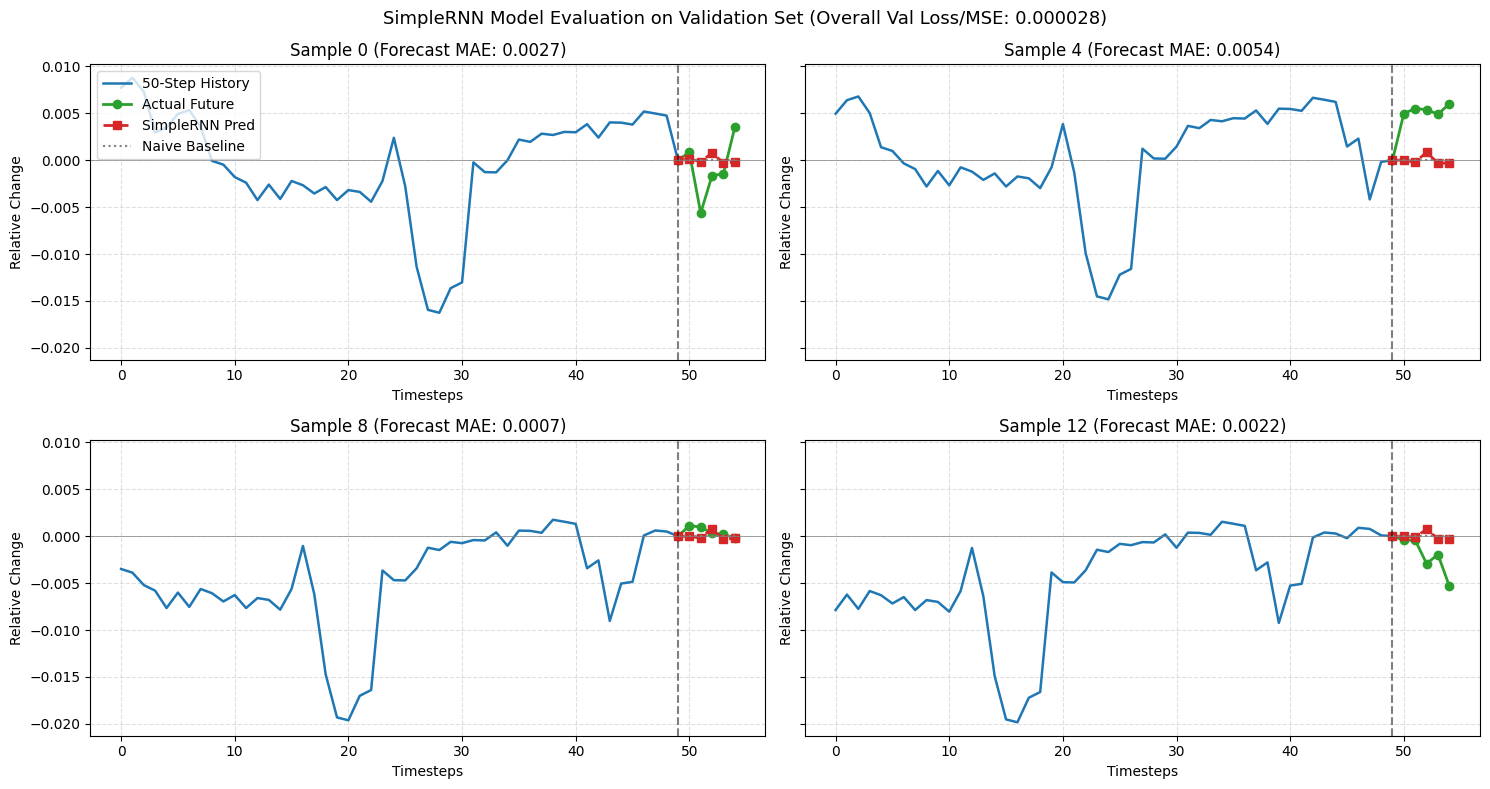

In [380]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Evaluate Overall Validation Performance
val_loss, val_mae = srnn_model2.evaluate(val_df_win_rebase, verbose=0)
val_rmse = np.sqrt(val_loss)

# 2. Extract Ground Truth Targets and Generate Predictions
y_val_true_list = []
for _, y_batch in val_df_win_rebase:
    y_val_true_list.append(y_batch.numpy())

y_val_true = np.concatenate(y_val_true_list, axis=0)
y_val_pred = srnn_model2.predict(val_df_win_rebase, verbose=0)
y_val_naive = np.zeros_like(y_val_true)

# Benchmark Naive Baseline
naive_mse = mean_squared_error(y_val_true, y_val_naive)
naive_rmse = np.sqrt(naive_mse)
naive_mae = mean_absolute_error(y_val_true, y_val_naive)

# Print Metrics Summary Table
print(f"{'Metric':<8} | {'SimpleRNN':<14} | {'Naive Baseline':<14} | {'Beats Naive?'}")
print("-" * 55)
print(f"{'MSE':<8} | {val_loss:<14.6f} | {naive_mse:<14.6f} | {'YES' if val_loss < naive_mse else 'NO'}")
print(f"{'RMSE':<8} | {val_rmse:<14.6f} | {naive_rmse:<14.6f} | {'YES' if val_rmse < naive_rmse else 'NO'}")
print(f"{'MAE':<8} | {val_mae:<14.6f} | {naive_mae:<14.6f} | {'YES' if val_mae < naive_mae else 'NO'}")

print("\n--- MAE by Forecast Horizon ---")
for day in range(5):
    step_rnn_mae = mean_absolute_error(y_val_true[:, day], y_val_pred[:, day])
    step_naive_mae = mean_absolute_error(y_val_true[:, day], y_val_naive[:, day])
    delta = (step_rnn_mae - step_naive_mae) / step_naive_mae * 100
    print(f"Day {day + 1}: RNN = {step_rnn_mae:.4%}, Naive = {step_naive_mae:.4%} ({delta:+.2f}%)")

# 3. Multi-Sample Forecast Visualizations
for x_batch, y_batch in val_df_win_rebase.skip(1).take(1):
    x_sample_batch = x_batch.numpy()
    y_sample_true = y_batch.numpy()
    break

y_sample_pred = srnn_model2.predict(x_sample_batch, verbose=0)

t_hist = np.arange(0, 50)
t_future = np.arange(49, 55)

sample_indices = [0, 4, 8, 12]
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    h = x_sample_batch[idx].flatten()
    act = np.insert(y_sample_true[idx].flatten(), 0, h[-1])
    prd = np.insert(y_sample_pred[idx].flatten(), 0, h[-1])
    
    # Calculate sample-level metrics
    s_mae = mean_absolute_error(act[1:], prd[1:])
    
    ax.plot(t_hist, h, color="#1f77b4", linewidth=1.8, label="50-Step History")
    ax.plot(t_future, act, color="#2ca02c", marker="o", linewidth=2, label="Actual Future")
    ax.plot(t_future, prd, color="#d62728", linestyle="--", marker="s", linewidth=2, label="SimpleRNN Pred")
    ax.plot(t_future, [0.0] * len(t_future), color="gray", linestyle=":", label="Naive Baseline")
    
    ax.axvline(49, color="black", linestyle="--", alpha=0.5)
    ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)
    ax.set_title(f"Sample {idx} (Forecast MAE: {s_mae:.4f})")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Relative Change")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].legend(loc="upper left")
plt.suptitle(f"SimpleRNN Model Evaluation on Validation Set (Overall Val Loss/MSE: {val_loss:.6f})", fontsize=13)
plt.tight_layout()
plt.show()

## 3.2.4 Gru

In [382]:
gru_model2 = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(64),
    keras.layers.Dense(5)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.008)
gru_model2.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

gru_model2.fit(train_df_win_rebase, validation_data=val_df_win_rebase, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 63s 60ms/step - loss: 2.1954e-04 - mae: 0.0060 - val_loss: 3.2315e-05 - val_mae: 0.0036 - learning_rate: 0.0080
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 62s 61ms/step - loss: 3.4301e-05 - mae: 0.0037 - val_loss: 8.3686e-05 - val_mae: 0.0075 - learning_rate: 0.0080
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 64s 63ms/step - loss: 3.6842e-05 - mae: 0.0039 - val_loss: 2.9135e-05 - val_mae: 0.0031 - learning_rate: 0.0080
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 63s 62ms/step - loss: 3.4934e-05 - mae: 0.0036 - val_loss: 3.0707e-05 - val_mae: 0.0034 - learning_rate: 0.0080
Epoch 5/50
1014/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 3.5082e-05 - mae: 0.0037
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.004000000189989805.
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 63s 61ms/step - loss: 3.5075e-05 - mae: 0.0037 - val_loss: 2.9328e-05 - val_mae: 0.0032 - learning_rate: 0.0080
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 62s 61ms/step - loss: 3.2727e-05 - m

Metric   | Stacked GRU    | Naive Baseline | Beats Naive?
-------------------------------------------------------
MSE      | 0.000029       | 0.000028       | NO
RMSE     | 0.005390       | 0.005315       | NO
MAE      | 0.003174       | 0.002991       | NO

--- MAE by Horizon Step ---
Day 1: GRU = 0.1907%, Naive = 0.1686% (+13.14%)
Day 2: GRU = 0.2661%, Naive = 0.2464% (+7.99%)
Day 3: GRU = 0.3356%, Naive = 0.3088% (+8.67%)
Day 4: GRU = 0.3783%, Naive = 0.3619% (+4.54%)
Day 5: GRU = 0.4162%, Naive = 0.4099% (+1.54%)


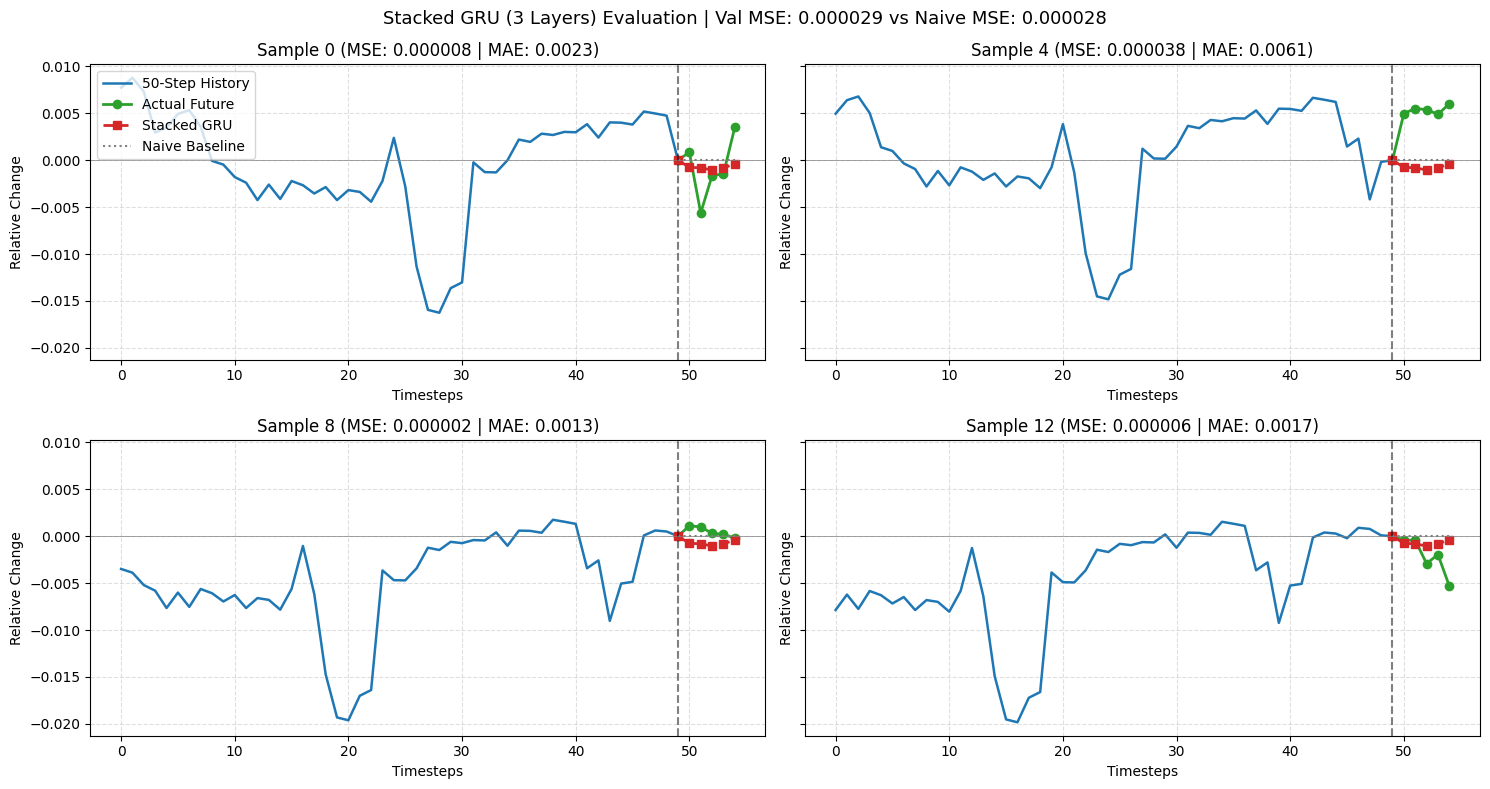

In [383]:
# 1. Evaluate Overall Metrics across Full Validation Pipeline
val_loss, val_mae = gru_model2.evaluate(val_df_win_rebase, verbose=0)
val_rmse = np.sqrt(val_loss)

# 2. Extract Validation Ground Truth and Run Full Inference
y_val_true_list = []
for _, y_batch in val_df_win_rebase:
    y_val_true_list.append(y_batch.numpy())

y_val_true = np.concatenate(y_val_true_list, axis=0)
y_val_pred = gru_model2.predict(val_df_win_rebase, verbose=0)
y_val_naive = np.zeros_like(y_val_true)

# 3. Benchmark Against Naive Baseline (Flat at 0.0)
naive_mse = mean_squared_error(y_val_true, y_val_naive)
naive_rmse = np.sqrt(naive_mse)
naive_mae = mean_absolute_error(y_val_true, y_val_naive)

print(f"{'Metric':<8} | {'Stacked GRU':<14} | {'Naive Baseline':<14} | {'Beats Naive?'}")
print("-" * 55)
print(f"{'MSE':<8} | {val_loss:<14.6f} | {naive_mse:<14.6f} | {'YES' if val_loss < naive_mse else 'NO'}")
print(f"{'RMSE':<8} | {val_rmse:<14.6f} | {naive_rmse:<14.6f} | {'YES' if val_rmse < naive_rmse else 'NO'}")
print(f"{'MAE':<8} | {val_mae:<14.6f} | {naive_mae:<14.6f} | {'YES' if val_mae < naive_mae else 'NO'}")

print("\n--- MAE by Horizon Step ---")
for step in range(5):
    step_gru_mae = mean_absolute_error(y_val_true[:, step], y_val_pred[:, step])
    step_naive_mae = mean_absolute_error(y_val_true[:, step], y_val_naive[:, step])
    delta = (step_gru_mae - step_naive_mae) / step_naive_mae * 100
    print(f"Day {step + 1}: GRU = {step_gru_mae:.4%}, Naive = {step_naive_mae:.4%} ({delta:+.2f}%)")

# 4. Multi-Sample Trajectory Visualizations
for x_batch, y_batch in val_df_win_rebase.skip(1).take(1):
    x_sample_batch = x_batch.numpy()
    y_sample_true = y_batch.numpy()
    break

y_sample_pred = gru_model2.predict(x_sample_batch, verbose=0)

t_hist = np.arange(0, 50)
t_future = np.arange(49, 55)

sample_indices = [0, 4, 8, 12]
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    h = x_sample_batch[idx].flatten()
    act = np.insert(y_sample_true[idx].flatten(), 0, h[-1])
    prd = np.insert(y_sample_pred[idx].flatten(), 0, h[-1])
    
    s_mae = mean_absolute_error(act[1:], prd[1:])
    s_mse = mean_squared_error(act[1:], prd[1:])
    
    ax.plot(t_hist, h, color="#1f77b4", linewidth=1.8, label="50-Step History")
    ax.plot(t_future, act, color="#2ca02c", marker="o", linewidth=2, label="Actual Future")
    ax.plot(t_future, prd, color="#d62728", linestyle="--", marker="s", linewidth=2, label="Stacked GRU")
    ax.plot(t_future, [0.0] * len(t_future), color="gray", linestyle=":", label="Naive Baseline")
    
    ax.axvline(49, color="black", linestyle="--", alpha=0.5)
    ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)
    ax.set_title(f"Sample {idx} (MSE: {s_mse:.6f} | MAE: {s_mae:.4f})")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Relative Change")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].legend(loc="upper left")
plt.suptitle(f"Stacked GRU (3 Layers) Evaluation | Val MSE: {val_loss:.6f} vs Naive MSE: {naive_mse:.6f}", fontsize=13)
plt.tight_layout()
plt.show()

## 3.2.5 LSTM model

In [385]:
lstm_model2 = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(64),
    keras.layers.Dense(5)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
lstm_model2.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=4,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)

lstm_model2.fit(train_df_win_rebase, validation_data=val_df_win_rebase, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 66s 63ms/step - loss: 3.5130e-05 - mae: 0.0037 - val_loss: 2.8851e-05 - val_mae: 0.0031 - learning_rate: 0.0010
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 64s 63ms/step - loss: 3.2718e-05 - mae: 0.0034 - val_loss: 2.8485e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 65s 64ms/step - loss: 3.2657e-05 - mae: 0.0034 - val_loss: 2.8477e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 64s 63ms/step - loss: 3.1782e-05 - mae: 0.0034 - val_loss: 2.8315e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 5/50
1014/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 3.2593e-05 - mae: 0.0034
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 64s 63ms/step - loss: 3.2587e-05 - mae: 0.0034 - val_loss: 2.8367e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 64s 63ms/step - loss: 3.2168e-05 - 

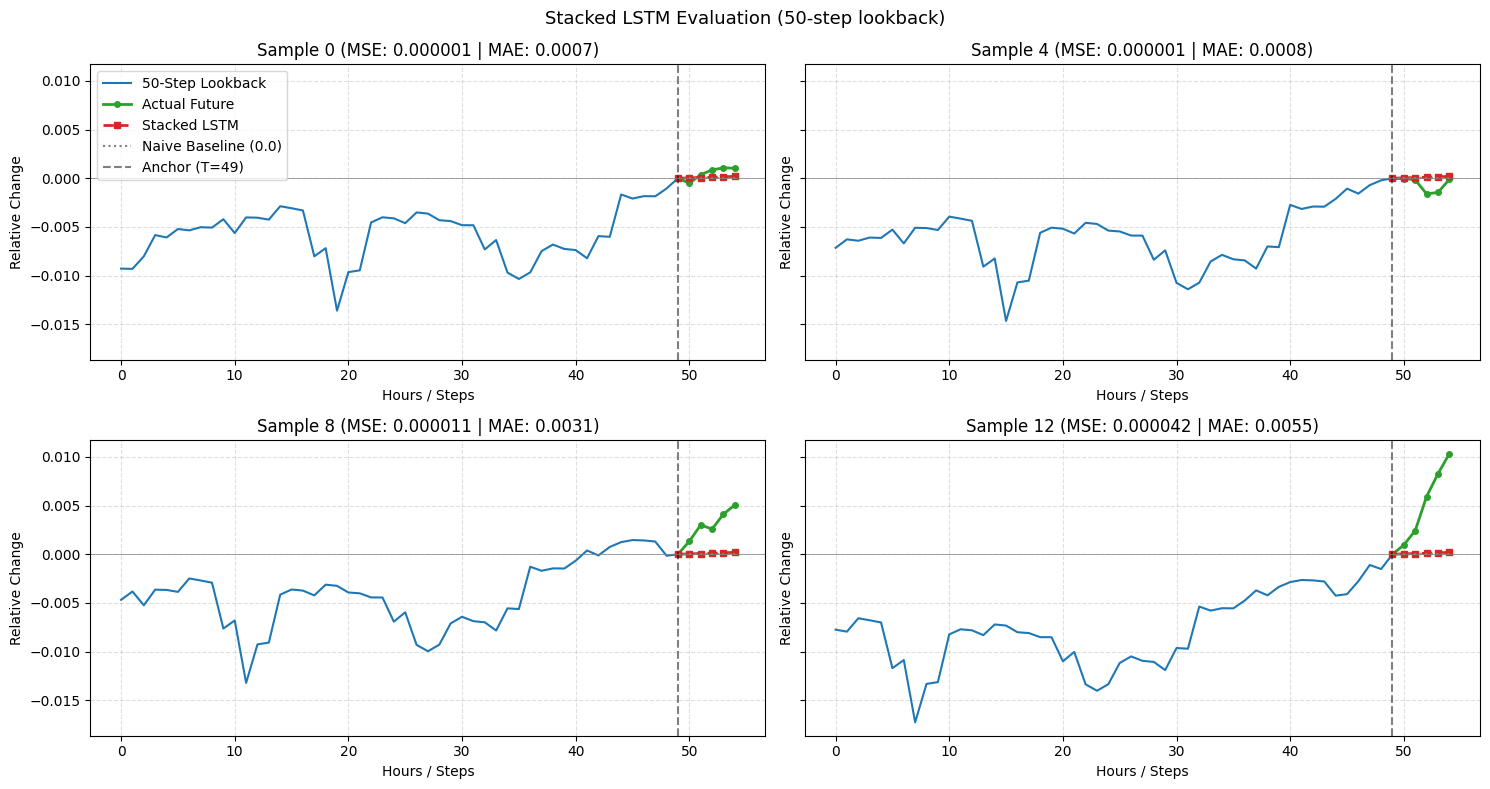

In [389]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Grab a validation batch and infer lookback length dynamically
for x_batch, y_batch in val_df_win_rebase.skip(2).take(1):
    x_sample_batch = x_batch.numpy()
    y_sample_true = y_batch.numpy()
    break

# Dynamically extract lookback size (e.g., 50 or 120)
LOOKBACK = x_sample_batch.shape[1]
FORECAST = y_sample_true.shape[1]
anchor_idx = LOOKBACK - 1

# 2. Run inference on the batch
y_sample_pred = lstm_model2.predict(x_sample_batch, verbose=0)

# 3. Dynamic time axes based on the detected lookback
t_hist = np.arange(0, LOOKBACK)
t_future = np.arange(anchor_idx, anchor_idx + FORECAST + 1)

# 4. Multi-sample plots
sample_indices = [0, 4, 8, 12]
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    h = x_sample_batch[idx].flatten()
    act = np.insert(y_sample_true[idx].flatten(), 0, h[-1])
    prd = np.insert(y_sample_pred[idx].flatten(), 0, h[-1])
    
    s_mae = mean_absolute_error(act[1:], prd[1:])
    s_mse = mean_squared_error(act[1:], prd[1:])
    
    ax.plot(t_hist, h, color="#1f77b4", linewidth=1.5, label=f"{LOOKBACK}-Step Lookback")
    ax.plot(t_future, act, color="#2ca02c", marker="o", markersize=4, linewidth=2, label="Actual Future")
    ax.plot(t_future, prd, color="#d62728", linestyle="--", marker="s", markersize=4, linewidth=2, label="Stacked LSTM")
    ax.plot(t_future, [0.0] * len(t_future), color="gray", linestyle=":", label="Naive Baseline (0.0)")
    
    ax.axvline(anchor_idx, color="black", linestyle="--", alpha=0.5, label=f"Anchor (T={anchor_idx})")
    ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)
    ax.set_title(f"Sample {idx} (MSE: {s_mse:.6f} | MAE: {s_mae:.4f})")
    ax.set_xlabel("Hours / Steps")
    ax.set_ylabel("Relative Change")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].legend(loc="upper left")
plt.suptitle(f"Stacked LSTM Evaluation ({LOOKBACK}-step lookback)", fontsize=13)
plt.tight_layout()
plt.show()

## 3.3.1 GRU model

In [391]:
gru_model3 = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(64),
    keras.layers.Dense(5)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
gru_model3.compile(loss="mse", optimizer=optimizer)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    min_lr=1e-6,
    factor=0.5
)
gru_model3.fit(train_df_win_rebase120, validation_data=val_df_win_rebase120, epochs=50, callbacks=[early_stop, reduce_lr])


Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 141s 137ms/step - loss: 4.2754e-05 - val_loss: 2.8720e-05 - learning_rate: 0.0010
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 139s 137ms/step - loss: 3.3601e-05 - val_loss: 2.8902e-05 - learning_rate: 0.0010
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 140s 138ms/step - loss: 3.1359e-05 - val_loss: 2.8877e-05 - learning_rate: 0.0010
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 142s 140ms/step - loss: 3.2735e-05 - val_loss: 2.8538e-05 - learning_rate: 0.0010
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 142s 140ms/step - loss: 3.3527e-05 - val_loss: 2.8392e-05 - learning_rate: 5.0000e-04
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 139s 137ms/step - loss: 3.1787e-05 - val_loss: 2.8542e-05 - learning_rate: 5.0000e-04
Epoch 7/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 141s 139ms/step - loss: 3.2347e-05 - val_loss: 2.8511e-05 - learning_rate: 5.0000e-04
Epoch 8/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 139s 137ms/step - loss: 3.3875e-05 - val_loss: 2.8383e-05 - learning_rate: 2.5

Metric   | GRU Model 3    | Naive Baseline | Beats Naive?
-------------------------------------------------------
MSE      | 0.000028       | 0.000028       | YES
RMSE     | 0.005319       | 0.005320       | YES
MAE      | 0.002988       | 0.002991       | YES


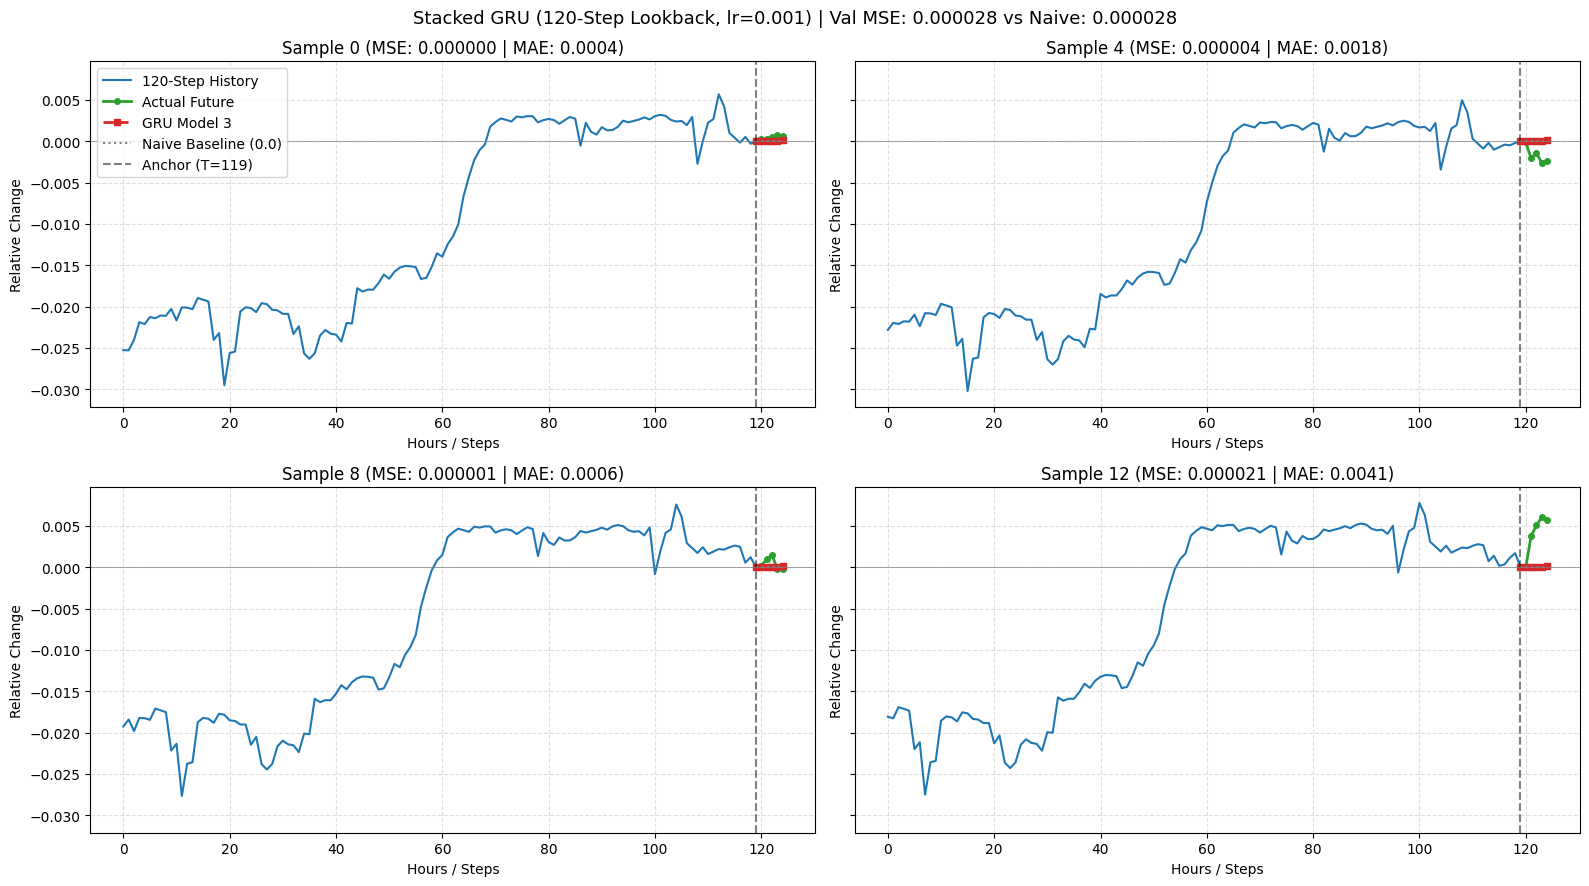

In [394]:
# 1. Compute Full Validation Metrics
val_loss = gru_model3.evaluate(val_df_win_rebase120, verbose=0)
val_rmse = np.sqrt(val_loss)

# 2. Extract Validation Ground Truth and Run Model Inference
y_val_true_list = []
for _, y_batch in val_df_win_rebase120:
    y_val_true_list.append(y_batch.numpy())

y_val_true = np.concatenate(y_val_true_list, axis=0)
y_val_pred = gru_model3.predict(val_df_win_rebase120, verbose=0)
y_val_naive = np.zeros_like(y_val_true)

# Naive Baseline Benchmark (Flat line at 0.0)
naive_mse = mean_squared_error(y_val_true, y_val_naive)
naive_rmse = np.sqrt(naive_mse)
naive_mae = mean_absolute_error(y_val_true, y_val_naive)
val_mae = mean_absolute_error(y_val_true, y_val_pred)

print(f"{'Metric':<8} | {'GRU Model 3':<14} | {'Naive Baseline':<14} | {'Beats Naive?'}")
print("-" * 55)
print(f"{'MSE':<8} | {val_loss:<14.6f} | {naive_mse:<14.6f} | {'YES' if val_loss < naive_mse else 'NO'}")
print(f"{'RMSE':<8} | {val_rmse:<14.6f} | {naive_rmse:<14.6f} | {'YES' if val_rmse < naive_rmse else 'NO'}")
print(f"{'MAE':<8} | {val_mae:<14.6f} | {naive_mae:<14.6f} | {'YES' if val_mae < naive_mae else 'NO'}")

# 3. Grab a Batch for Trajectory Plots
for x_batch, y_batch in val_df_win_rebase120.skip(2).take(1):
    x_sample_batch = x_batch.numpy()
    y_sample_true = y_batch.numpy()
    break

# Dynamically extract lookback dimensions
lookback_len = x_sample_batch.shape[1]   # 120
forecast_len = y_sample_true.shape[1]    # 5
anchor_idx = lookback_len - 1            # 119

y_sample_pred = gru_model3.predict(x_sample_batch, verbose=0)

# 4. Multi-Sample Trajectory Visualizations
t_hist = np.arange(0, lookback_len)
t_future = np.arange(anchor_idx, anchor_idx + forecast_len + 1)

sample_indices = [0, 4, 8, 12]
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    h = x_sample_batch[idx].flatten()
    act = np.insert(y_sample_true[idx].flatten(), 0, h[-1])
    prd = np.insert(y_sample_pred[idx].flatten(), 0, h[-1])
    
    s_mse = mean_squared_error(act[1:], prd[1:])
    s_mae = mean_absolute_error(act[1:], prd[1:])
    
    ax.plot(t_hist, h, color="#1f77b4", linewidth=1.5, label=f"{lookback_len}-Step History")
    ax.plot(t_future, act, color="#2ca02c", marker="o", markersize=4, linewidth=2, label="Actual Future")
    ax.plot(t_future, prd, color="#d62728", linestyle="--", marker="s", markersize=4, linewidth=2, label="GRU Model 3")
    ax.plot(t_future, [0.0] * len(t_future), color="gray", linestyle=":", label="Naive Baseline (0.0)")
    
    ax.axvline(anchor_idx, color="black", linestyle="--", alpha=0.5, label=f"Anchor (T={anchor_idx})")
    ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)
    ax.set_title(f"Sample {idx} (MSE: {s_mse:.6f} | MAE: {s_mae:.4f})")
    ax.set_xlabel("Hours / Steps")
    ax.set_ylabel("Relative Change")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].legend(loc="upper left")
plt.suptitle(f"Stacked GRU (120-Step Lookback, lr=0.001) | Val MSE: {val_loss:.6f} vs Naive: {naive_mse:.6f}", fontsize=13)
plt.tight_layout()
plt.show()

## 3.3.2 Conv1D model with increasing dilation rate

In [398]:
conv1d_model = keras.models.Sequential([
    keras.layers.Input(shape=(None, 1)),
    
    # Layer 1: Captures short-term local fluctuations (effective window: 3)
    keras.layers.Conv1D(filters=32, kernel_size=3, padding="causal", dilation_rate=1, activation="relu"),
    keras.layers.BatchNormalization(),
    
    # Layer 2: Captures swing moves (dilation=2, effective span: ~7 steps)
    keras.layers.Conv1D(filters=64, kernel_size=3, padding="causal", dilation_rate=2, activation="relu"),
    keras.layers.BatchNormalization(),
    
    # Layer 3: Captures multi-day cycles (dilation=4, effective span: ~15 steps)
    keras.layers.Conv1D(filters=64, kernel_size=3, padding="causal", dilation_rate=4, activation="relu"),
    keras.layers.BatchNormalization(),
    
    # Layer 4: Sees broad macro trends across the 120-step history (dilation=8)
    keras.layers.Conv1D(filters=128, kernel_size=3, padding="causal", dilation_rate=8, activation="relu"),
    keras.layers.BatchNormalization(),
    
    # Pool across sequence length to compress into a dense representation
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(5)  # 5-step relative price change
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
conv1d_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

conv1d_model.fit(
    train_df_win_rebase120,
    validation_data=val_df_win_rebase120,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.0400 - mae: 0.1063 - val_loss: 3.2420e-05 - val_mae: 0.0034 - learning_rate: 0.0010
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 1.4978e-04 - mae: 0.0059 - val_loss: 2.8412e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5.3827e-05 - mae: 0.0040 - val_loss: 2.8319e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 4/50
1009/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.7962e-05 - mae: 0.0036
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.7946e-05 - mae: 0.0036 - val_loss: 2.8328e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.5815e-05 - mae: 0.0035 - val_loss: 2.8309e-05 - val_mae: 0.0030 - learning_rate: 5.0000e-04
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 3.4435e-05 - 

In [400]:
reg_conv1d = keras.models.Sequential([
    keras.layers.Input(shape=(120, 1)),
    
    # Layer 1: k=3, dilation=1
    keras.layers.Conv1D(
        filters=16, kernel_size=3, padding="causal", dilation_rate=1, 
        activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    keras.layers.SpatialDropout1D(0.1),
    
    # Layer 2: k=3, dilation=2
    keras.layers.Conv1D(
        filters=32, kernel_size=3, padding="causal", dilation_rate=2, 
        activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    keras.layers.SpatialDropout1D(0.1),
    
    # Layer 3: k=3, dilation=4
    keras.layers.Conv1D(
        filters=32, kernel_size=3, padding="causal", dilation_rate=4, 
        activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    
    # Layer 4: k=3, dilation=8
    keras.layers.Conv1D(
        filters=64, kernel_size=3, padding="causal", dilation_rate=8, 
        activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(5)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
reg_conv1d.compile(loss="mse", metrics=["mae"], optimizer=optimizer)
reg_conv1d.fit(train_df_win_rebase120, validation_data=val_df_win_rebase120, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0018 - mae: 0.0034 - val_loss: 2.8357e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 2/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 3.1972e-05 - mae: 0.0034 - val_loss: 2.8403e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 3/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 3.1992e-05 - mae: 0.0034 - val_loss: 2.8505e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 4/20
1011/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2117e-05 - mae: 0.0034
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 3.2112e-05 - mae: 0.0034 - val_loss: 2.8355e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 5/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 3.2625e-05 - mae: 0.0034 - val_loss: 2.8316e-05 - val_mae: 0.0030 - learning_rate: 5.0000e-04
Epoch 6/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 3.2302e-05 - mae: 0.0033 -

## 3.3.3 Conv1D with RNN model

In [402]:
# 1. Model Definition: Conv1D -> GRU Hybrid
conv_rnn_model = keras.models.Sequential([
    keras.layers.Input(shape=(120, 1)),

    # Feature Extractor: filters local patterns & downsamples (stride=2 -> 120 steps to 60 steps)
    keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        strides=2,
        padding="same",
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    ),
    keras.layers.SpatialDropout1D(0.15),

    # Second Conv layer to extract higher-level swing combinations
    keras.layers.Conv1D(
        filters=32,
        kernel_size=3,
        strides=1,
        padding="same",
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    ),

    # Recurrent Layer: processes the 60 compressed temporal representations
    keras.layers.GRU(48, return_sequences=False),
    keras.layers.Dropout(0.25),

    # Projection Head: predicts the 5-step relative path
    keras.layers.Dense(24, activation="relu"),
    keras.layers.Dense(5)
])

# 2. Compile with gradient clipping to prevent recurrent explosion
optimizer = keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
conv_rnn_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

conv_rnn_model.fit(train_df_win_rebase120, validation_data=val_df_win_rebase120, epochs=20, callbacks=[early_stop, reduce_lr])

Epoch 1/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 6.5623e-04 - mae: 0.0034 - val_loss: 2.8595e-05 - val_mae: 0.0031 - learning_rate: 0.0010
Epoch 2/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.2596e-05 - mae: 0.0034 - val_loss: 2.8368e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 3/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.1755e-05 - mae: 0.0034 - val_loss: 3.0163e-05 - val_mae: 0.0034 - learning_rate: 0.0010
Epoch 4/20
1009/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.2694e-05 - mae: 0.0034
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.2681e-05 - mae: 0.0034 - val_loss: 2.9029e-05 - val_mae: 0.0032 - learning_rate: 0.0010
Epoch 5/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.0985e-05 - mae: 0.0033 - val_loss: 2.8591e-05 - val_mae: 0.0030 - learning_rate: 5.0000e-04
Epoch 6/20
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.3239e-0

## 3.3.4 Encoder Decoder network

In [403]:
# Latent subspace bottleneck size
LATENT_DIM = 64
FORECAST_STEPS = 5

encoder_decoder = keras.models.Sequential([
    # --- ENCODER ---
    # Ingests (batch, 120, 1) and encodes temporal dynamics
    keras.layers.Input(shape=(None, 1)),
    keras.layers.GRU(96, return_sequences=True, kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dropout(0.2),
    # Bottleneck: returns only the final hidden state (batch, 64) -> Latent Space Vector
    keras.layers.GRU(LATENT_DIM, return_sequences=False, kernel_regularizer=keras.regularizers.l2(1e-4)),
    
    # --- LATENT BRIDGE ---
    # Replicates the 64-dimensional latent embedding across the 5 output steps
    keras.layers.RepeatVector(FORECAST_STEPS),  # Shape: (batch, 5, 64)
    
    # --- DECODER ---
    # Unrolls step-by-step from the latent representation
    keras.layers.GRU(64, return_sequences=True, kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dropout(0.2),
    # Project each of the 5 unrolled states into continuous relative predictions
    keras.layers.TimeDistributed(keras.layers.Dense(32, activation="relu")),
    keras.layers.TimeDistributed(keras.layers.Dense(1)),
    
    # Reshape from (batch, 5, 1) to (batch, 5) to match y_true
    keras.layers.Reshape((FORECAST_STEPS,))
])

optimizer = keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
encoder_decoder.compile(loss="mse", metrics=["mae"], optimizer=optimizer)

encoder_decoder.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_12 (GRU)                    │ (None, None, 96)       │        28,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, None, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_13 (GRU)                    │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_14 (GRU)                    │ (None, 5, 64)          │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 32)          │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_11 (Reshape)            │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,689 (338.63 KB)

 Trainable params: 86,689 (338.63 KB)

 Non-trainable params: 0 (0.00 B)

In [404]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

history = encoder_decoder.fit(
    train_df_win_rebase120,
    validation_data=val_df_win_rebase120,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 70s 66ms/step - loss: 0.0038 - mae: 0.0035 - val_loss: 2.8751e-05 - val_mae: 0.0031 - learning_rate: 0.0010
Epoch 2/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - loss: 3.1538e-05 - mae: 0.0034 - val_loss: 2.8302e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 3/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 65s 64ms/step - loss: 3.2263e-05 - mae: 0.0034 - val_loss: 2.8293e-05 - val_mae: 0.0030 - learning_rate: 0.0010
Epoch 4/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 3.3228e-05 - mae: 0.0034
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 65s 64ms/step - loss: 3.3224e-05 - mae: 0.0034 - val_loss: 2.8856e-05 - val_mae: 0.0031 - learning_rate: 0.0010
Epoch 5/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 66s 64ms/step - loss: 3.1948e-05 - mae: 0.0034 - val_loss: 2.8479e-05 - val_mae: 0.0030 - learning_rate: 5.0000e-04
Epoch 6/50
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - loss: 3.2433e-05 - 

# Major Observation

Across all the models and all the data ingestion pipeline I used, there is this validation loss border, namely 2.83e-5, which none of the models could move past. Visualizing the outputted models yields the following explanation. None of the models could generalize well for the nasdaq price action, so the best they could do to minimize the mean squared error is to converge to predicting values that fall really close to the last time step. That is why on the plots the predictions are rather a horizontal line than actual price action forecast, and why I the complex model` MSE is close to the Naive MSE.

It is well know that the financial market is non-stationary and models do need stationary data to generalize. Even tough I created stationary data using relative pricing in the batches it was not enough. The singal-to-noise ratio is still tiny. If I would have created a model that could predict the next 5 moves, then it would not work for long, because the market always searches for alphas. If I were to have a positive alpha that would not stay that for long. Alphas decay overtime that is why its so hard to build a forecast model when the input data is not stationary and controlled by traders with their own emotions and discretionary rules.

Another approach for the financial market is it predict the regimes that are currently on the market rather than predicting the next x timesteps of the asset. This could mean predicting bullish, bearish or sideways market. Or predicting the size of the next day`s candle in bins. (not actualy size, because that once again regression)

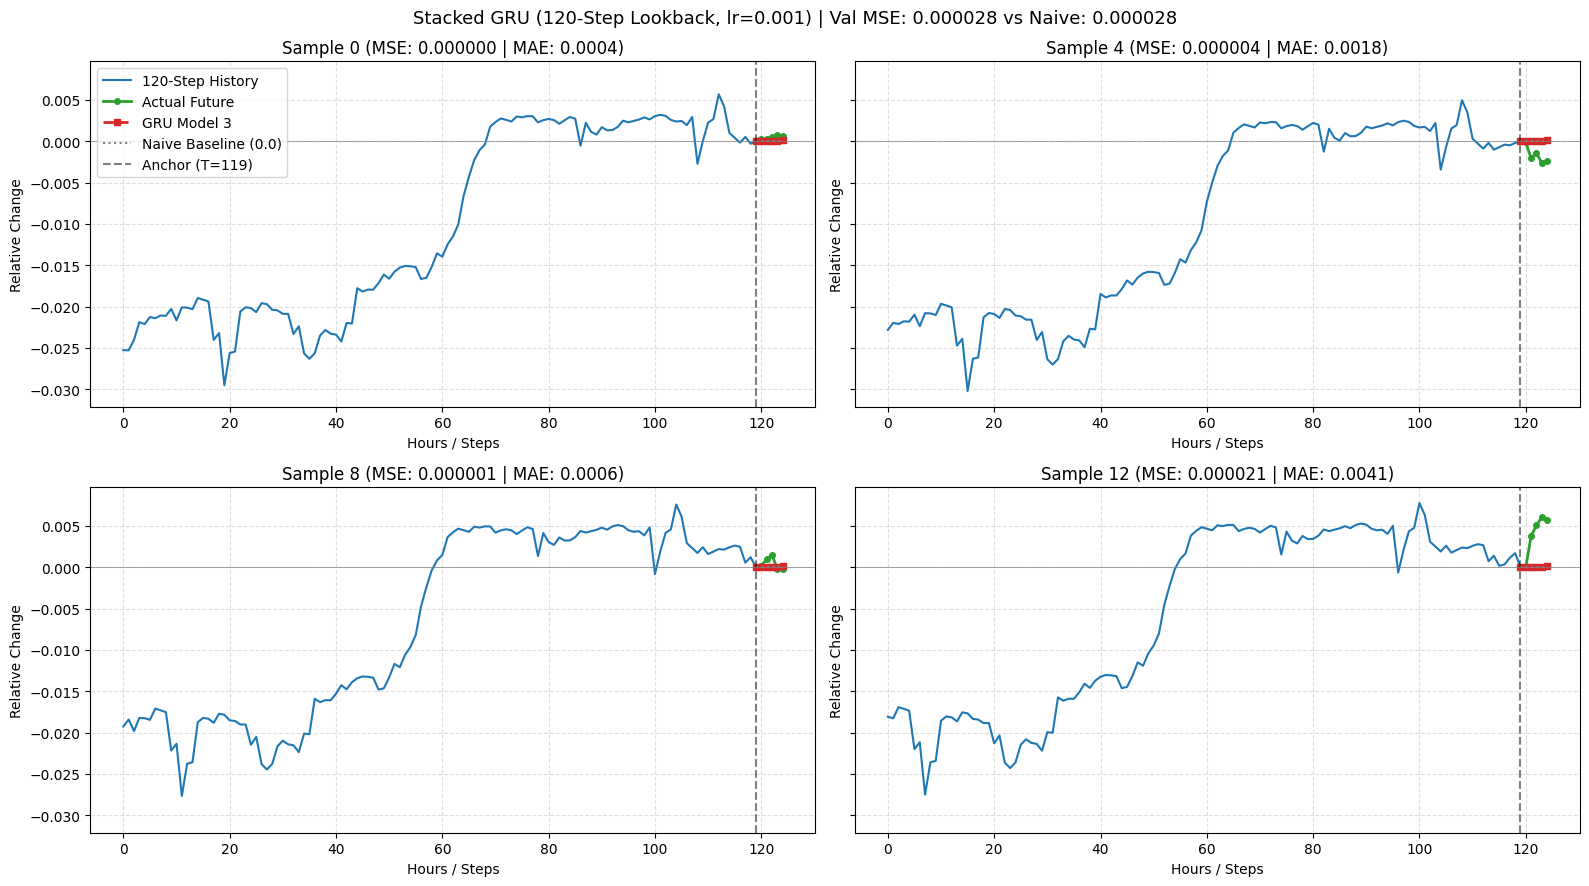